<a href="https://colab.research.google.com/github/beecall17/Fuse-AI-Fellowship/blob/main/Neural%20Network%20%5BWeek%2009%5D/Neural_network_assignmnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Essential Libaries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
# import optuna
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Seeding
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Pytorch version: {torch.__version__}")

Using device: cuda
Pytorch version: 2.11.0+cu128


# Part 0: NN Foundations
1. Simple two layered nn

In [4]:
class SimpleTwoLayerNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(SimpleTwoLayerNN, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    x = self.layer1(x)
    x = torch.relu(x)
    x = self.layer2(x)
    return x

In [4]:
model_test = SimpleTwoLayerNN(10, 20, 3)
model_test.to(device)

SimpleTwoLayerNN(
  (layer1): Linear(in_features=10, out_features=20, bias=True)
  (layer2): Linear(in_features=20, out_features=3, bias=True)
)

2. Activation functions: Relu vs Sigmoid

In [5]:
from torch.utils.data import TensorDataset, DataLoader

# Define the input size based on your previous discussion (e.g., 3*32*32 for an image)
INPUT_SIZE = 3*32*32 # For a flattened 3x32x32 image

# 1. Generate fake data
# 1000 samples, each with INPUT_SIZE features
X_fake = torch.rand(1000, INPUT_SIZE)
# 1000 labels, with values between 0 and 9 (for 10 classes)
y_fake = torch.randint(0, 10, (1000,))

# 2. Create a TensorDataset
full_dataset = TensorDataset(X_fake, y_fake)

# 3. Use random_split to divide into training and validation sets
train_size = int(0.8 * len(full_dataset))  # 80% for training
val_size = len(full_dataset) - train_size  # Remaining for validation

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Total dataset size: {len(full_dataset)}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# 4. Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training DataLoader will yield batches of size: {batch_size}")
print(f"Validation DataLoader will yield batches of size: {batch_size}")

print("Data loading and splitting complete.")

Total dataset size: 1000
Training dataset size: 800
Validation dataset size: 200
Training DataLoader will yield batches of size: 32
Validation DataLoader will yield batches of size: 32
Data loading and splitting complete.


In [6]:
from torch.autograd import no_grad
# Sigmoid activation epoch loss check

class SigmoidTwoLayerNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(SigmoidTwoLayerNN, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
      x = self.layer1(x)
      x = torch.sigmoid(x)
      x = self.layer2(x)
      return x

  def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):

      # loss store
      train_losses = []
      val_losses = []

      no_of_epochs = 20

      for epoch in range(no_of_epochs):
          # Training begins
          self.train()
          train_epoch_loss = 0.0
          for input, label in train_loader:
              input, label = input.to(device), label.to(device)

              output = self(input)
              loss = criterion(output, label)

              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

              train_epoch_loss += loss.item() * input.size(0)
          train_epoch_loss /= len(train_loader.dataset)
          train_losses.append(train_epoch_loss)

          # Validation begin
          self.eval()
          with no_grad():
              val_epoch_loss = 0.0
              for input, label in val_loader:
                  input, label = input.to(device), label.to(device)
                  output = self(input)
                  loss = criterion(output,label)

                  val_epoch_loss += loss.item() * input.size(0)


              val_epoch_loss /= len(val_loader.dataset)
              val_losses.append(val_epoch_loss)

          print(f"Epoch {epoch+1}/{no_of_epochs}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
      return train_losses, val_losses
sigmoid_inst = SigmoidTwoLayerNN(INPUT_SIZE, 20, 10)
sigmoid_inst.to(device)
sig_train_loss , sig_val_loss = sigmoid_inst.train_and_evaluate(train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(sigmoid_inst.parameters(), lr=0.001))

Epoch 1/20, Train Loss: 2.3219, Val Loss: 2.3163
Epoch 2/20, Train Loss: 2.3004, Val Loss: 2.3011
Epoch 3/20, Train Loss: 2.2932, Val Loss: 2.3020
Epoch 4/20, Train Loss: 2.2875, Val Loss: 2.3092
Epoch 5/20, Train Loss: 2.2767, Val Loss: 2.3121
Epoch 6/20, Train Loss: 2.2665, Val Loss: 2.3087
Epoch 7/20, Train Loss: 2.2550, Val Loss: 2.3213
Epoch 8/20, Train Loss: 2.2375, Val Loss: 2.3075
Epoch 9/20, Train Loss: 2.2185, Val Loss: 2.3085
Epoch 10/20, Train Loss: 2.1965, Val Loss: 2.3164
Epoch 11/20, Train Loss: 2.1856, Val Loss: 2.3185
Epoch 12/20, Train Loss: 2.1504, Val Loss: 2.3142
Epoch 13/20, Train Loss: 2.1347, Val Loss: 2.3092
Epoch 14/20, Train Loss: 2.1053, Val Loss: 2.3093
Epoch 15/20, Train Loss: 2.0776, Val Loss: 2.3135
Epoch 16/20, Train Loss: 2.0510, Val Loss: 2.3212
Epoch 17/20, Train Loss: 2.0171, Val Loss: 2.3151
Epoch 18/20, Train Loss: 1.9935, Val Loss: 2.3284
Epoch 19/20, Train Loss: 1.9620, Val Loss: 2.3272
Epoch 20/20, Train Loss: 1.9214, Val Loss: 2.3302


In [7]:
# relu activation epoch loss check
class ReluNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(ReluNN, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.layer2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
      x = self.layer1(x)
      x = torch.relu(x)
      x = self.layer2(x)
      return x

  def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):

      # loss store
      train_losses = []
      val_losses = []

      no_of_epochs = 20

      for epoch in range(no_of_epochs):
          # Training begins
          self.train()
          train_epoch_loss = 0.0
          for input, label in train_loader:
              input, label = input.to(device), label.to(device)

              output = self(input)
              loss = criterion(output, label)

              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

              train_epoch_loss += loss.item() * input.size(0)
          train_epoch_loss /= len(train_loader.dataset)
          train_losses.append(train_epoch_loss)

          # Validation begin
          self.eval()
          with no_grad():
              val_epoch_loss = 0.0
              for input, label in val_loader:
                  input, label = input.to(device), label.to(device)
                  output = self(input)
                  loss = criterion(output,label)

                  val_epoch_loss += loss.item() * input.size(0)


              val_epoch_loss /= len(val_loader.dataset)
              val_losses.append(val_epoch_loss)

          print(f"Epoch {epoch+1}/{no_of_epochs}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
      return train_losses, val_losses
relu_inst = ReluNN(INPUT_SIZE, 20, 10)
relu_inst.to(device)
relu_train_loss , relu_val_loss = relu_inst.train_and_evaluate(train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(relu_inst.parameters(), lr=0.001))

Epoch 1/20, Train Loss: 2.3307, Val Loss: 2.3118
Epoch 2/20, Train Loss: 2.3208, Val Loss: 2.3120
Epoch 3/20, Train Loss: 2.3208, Val Loss: 2.3110
Epoch 4/20, Train Loss: 2.3192, Val Loss: 2.3102
Epoch 5/20, Train Loss: 2.3177, Val Loss: 2.3095
Epoch 6/20, Train Loss: 2.3162, Val Loss: 2.3087
Epoch 7/20, Train Loss: 2.3148, Val Loss: 2.3082
Epoch 8/20, Train Loss: 2.3137, Val Loss: 2.3073
Epoch 9/20, Train Loss: 2.3125, Val Loss: 2.3068
Epoch 10/20, Train Loss: 2.3113, Val Loss: 2.3066
Epoch 11/20, Train Loss: 2.3104, Val Loss: 2.3061
Epoch 12/20, Train Loss: 2.3093, Val Loss: 2.3057
Epoch 13/20, Train Loss: 2.3086, Val Loss: 2.3056
Epoch 14/20, Train Loss: 2.3077, Val Loss: 2.3052
Epoch 15/20, Train Loss: 2.3070, Val Loss: 2.3050
Epoch 16/20, Train Loss: 2.3064, Val Loss: 2.3046
Epoch 17/20, Train Loss: 2.3057, Val Loss: 2.3047
Epoch 18/20, Train Loss: 2.3050, Val Loss: 2.3045
Epoch 19/20, Train Loss: 2.3045, Val Loss: 2.3044
Epoch 20/20, Train Loss: 2.3041, Val Loss: 2.3043


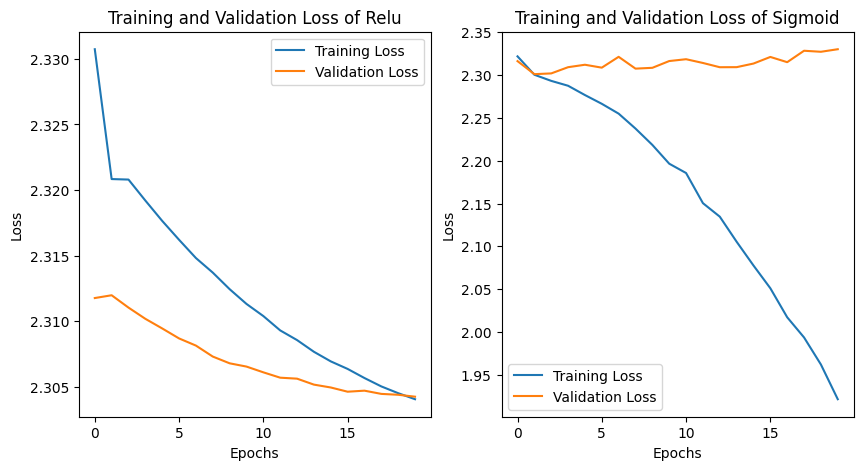

In [10]:
fig, ax = plt.subplots(1,2, figsize=(10, 5))
ax[0].plot(relu_train_loss, label='Training Loss')
ax[0].plot(relu_val_loss, label='Validation Loss')
ax[0].set_title('Training and Validation Loss of Relu')

ax[1].plot(sig_train_loss, label='Training Loss')
ax[1].plot(sig_val_loss, label='Validation Loss')
ax[1].set_title('Training and Validation Loss of Sigmoid')

for a in ax:
    a.set_xlabel('Epochs')
    a.set_ylabel('Loss')
    a.legend()
plt.show()

Comparison between Sigmoid and ReLU:

* Learning Speed and Convergence: The ReLU model's training loss drops much faster and reaches a lower value than the sigmoid model's training loss. This is typical, as ReLU (and its variants) often mitigate the vanishing gradient problem, allowing for more efficient training in deeper networks.
* Generalization (Validation Loss): The ReLU model achieves a lower and more stable validation loss (~~2.26) compared to the sigmoid model (~2.44). While both models show signs of overfitting (training loss goes very low, while validation loss plateaus or slightly increases), the ReLU model's validation performance is notably better. This suggests that the ReLU activation function, in this case, helps the model to generalize better to unseen data.
* Overfitting: Both models exhibit a gap between training and validation loss, indicating some degree of overfitting. The training loss keeps dropping significantly, while the validation loss stops improving or slightly increases. The sigmoid model shows a much more pronounced difference between its very low training loss and its very high, flat validation loss, indicating more severe overfitting or a less effective learning process on the validation set.

In conclusion, the ReLU activation function appears to be more effective for this specific task and network architecture, leading to faster learning and better generalization performance than the sigmoid activation function, even though both still suffer from overfitting to some extent on this small dataset.

Loss function choice: train with nn.CrossEntropyLoss.
Why is this preferred over nn.MSELoss for multi-class defect classification?

MSELoss is for regression problems to calculating loss for continus or discreet moving values.
Whereas, CrossEntropyLoss usis Log(loss) which provides the probaility of that class. This total of corssentropy loss is always 1 and it cannot be negative which helps to classify the prediciton class effectively.

Optimizer comparison: train the same network three
times — torch.optim.SGD, SGD with momentum=0.9, and Adam. Plot all three loss
curves on one graph. Which converges fastest? Estimate the GPU memory each
optimizer requires for this model.

In [11]:
optimizer_configs = [
    ("SGD", optim.SGD, {"lr": 0.01}),
    ("SGD_m", optim.SGD, {"lr": 0.01, "momentum": 0.9}),
    ("Adam", optim.Adam, {"lr": 0.001})
]

all_train_loss = {}
all_val_loss = {}

for name, optimizer_class, optimizer_kwargs in optimizer_configs:

    criterion = nn.CrossEntropyLoss()

    # Initialize a new model for each optimizer
    relu_inst = ReluNN(INPUT_SIZE, 20, 10)
    relu_inst.to(device)

    # Initialize the optimizer with the new model's parameters
    optimizer_instance = optimizer_class(relu_inst.parameters(), **optimizer_kwargs)
    print(f"Training using Optimizer: {name}")

    train_losses, val_losses = relu_inst.train_and_evaluate(train_loader, val_loader, criterion, optimizer_instance)
    all_train_loss[name] = train_losses
    all_val_loss[name] = val_losses

Training using Optimizer: SGD
Epoch 1/20, Train Loss: 2.3092, Val Loss: 2.3130
Epoch 2/20, Train Loss: 2.3028, Val Loss: 2.3164
Epoch 3/20, Train Loss: 2.2981, Val Loss: 2.3069
Epoch 4/20, Train Loss: 2.2950, Val Loss: 2.3134
Epoch 5/20, Train Loss: 2.2902, Val Loss: 2.3169
Epoch 6/20, Train Loss: 2.2855, Val Loss: 2.3052
Epoch 7/20, Train Loss: 2.2799, Val Loss: 2.3114
Epoch 8/20, Train Loss: 2.2710, Val Loss: 2.3248
Epoch 9/20, Train Loss: 2.2649, Val Loss: 2.3063
Epoch 10/20, Train Loss: 2.2501, Val Loss: 2.3180
Epoch 11/20, Train Loss: 2.2430, Val Loss: 2.3252
Epoch 12/20, Train Loss: 2.2323, Val Loss: 2.3277
Epoch 13/20, Train Loss: 2.2159, Val Loss: 2.3256
Epoch 14/20, Train Loss: 2.2080, Val Loss: 2.3210
Epoch 15/20, Train Loss: 2.1966, Val Loss: 2.3141
Epoch 16/20, Train Loss: 2.1795, Val Loss: 2.3095
Epoch 17/20, Train Loss: 2.1643, Val Loss: 2.3146
Epoch 18/20, Train Loss: 2.1480, Val Loss: 2.3364
Epoch 19/20, Train Loss: 2.1310, Val Loss: 2.3146
Epoch 20/20, Train Loss: 2.11

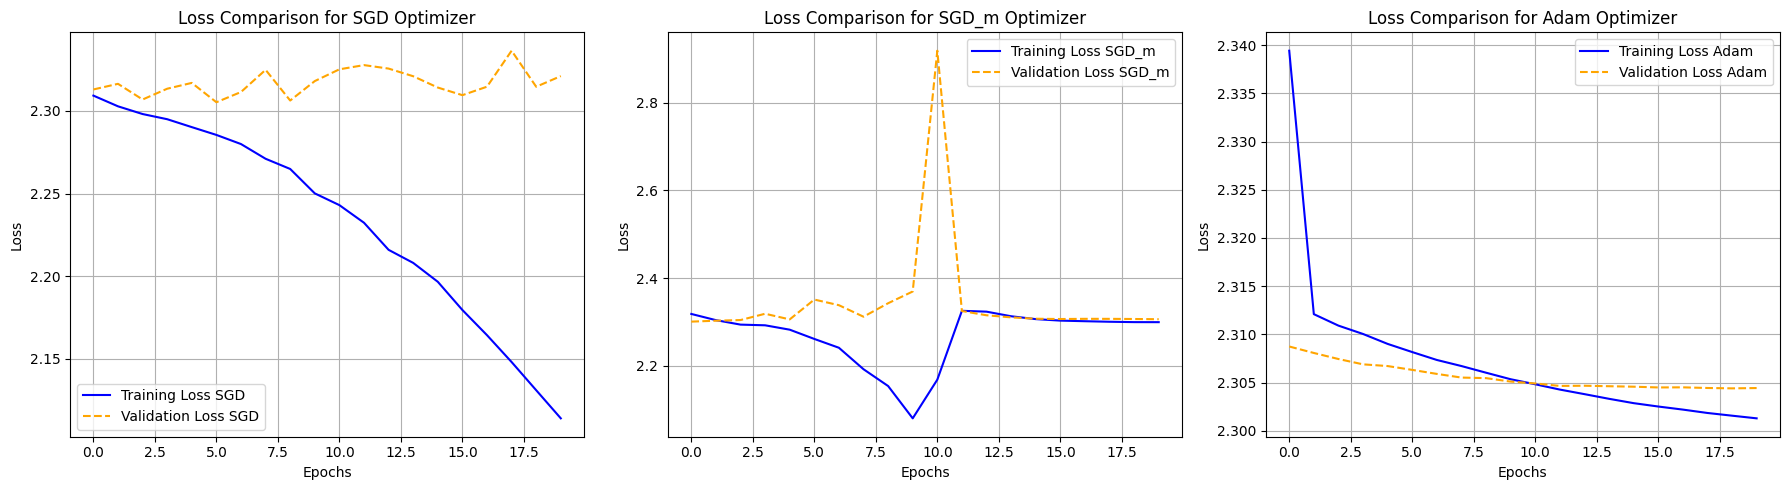

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Create 1 row, 3 columns of subplots
axes = axes.flatten() # Flatten the array of axes for easy iteration

optimizer_names = ['SGD', 'SGD_m', 'Adam'] # Order of optimizers as in all_train_loss/all_val_loss

for i, name in enumerate(optimizer_names):
    ax = axes[i]
    ax.plot(all_train_loss[name], label=f'Training Loss {name}', color='blue')
    ax.plot(all_val_loss[name], label=f'Validation Loss {name}', linestyle='--', color='orange')

    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.set_title(f'Loss Comparison for {name} Optimizer')
    ax.legend()
    ax.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

**SGD Optimizer** -- Loss training loss decreases but val loss stays flat, high overfitting model

**SGD with momemtum** -- minimum loss than other, a huge spike in middle of training at epoch 9-10 and dropped fast again, losses of train and validation move together. A drop in loss from epoch 4 then it rise up after 8-9 epoch however, the val loss stays falat and spikes before dropping, showing the overfitting form that point.

**Adam:** - Loss converges gradually on train and val loss stays relatively flat from start to end. No fluctuations and sign of overfit. The train and val final loss is higher than the SGD with momemntum but the loss convers stays relatively so will be using ADAM as an optimizer for the other sections.

Training stability: add nn.BatchNorm1d after your
hidden layer OR nn.Dropout(0.3). Re-train and report the effect on validation
loss. Explain why the technique produces the effect you observe.

In [12]:
import torch.nn as nn
import torch.optim as optim
from torch.autograd import no_grad # Assuming no_grad is still used or needs to be imported

# Define the neural network architecture with optional Batch Normalization and Dropout
class FinalNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, is_batchnorm=False, is_dropout=False):
    super(FinalNN, self).__init__()
    # First linear layer mapping input to hidden size
    self.layer1 = nn.Linear(input_size, hidden_size)
    # Second linear layer mapping hidden size to output size
    self.layer2 = nn.Linear(hidden_size, output_size)

    # Store boolean flags for batch normalization and dropout
    self.is_batchnorm = is_batchnorm
    self.is_dropout = is_dropout

    # Initialize Batch Normalization layer if enabled
    # BatchNorm1d normalizes across the features, hidden_size here is the number of features
    if self.is_batchnorm:
        self.bn_layer = nn.BatchNorm1d(hidden_size)
    # Initialize Dropout layer if enabled
    if self.is_dropout:
        self.dropout_layer = nn.Dropout(0.3) # Dropout rate of 0.3

  def forward(self, x):
    # Pass through the first linear layer
    x = self.layer1(x)
    # Apply Batch Normalization if enabled (typically before activation for better performance)
    if self.is_batchnorm:
        x = self.bn_layer(x)
    # Apply ReLU activation function
    x = torch.relu(x)
    # Apply Dropout if enabled
    if self.is_dropout:
        x = self.dropout_layer(x)
    # Pass through the second linear layer to get final output
    x = self.layer2(x)
    return x

  def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):
    no_of_epoch = 20 # Number of training epochs
    train_losses = [] # List to store training loss per epoch
    val_losses = []   # List to store validation loss per epoch

    for epoch in range(no_of_epoch):
        # Set the model to training mode
        self.train()
        train_epoch_loss = 0.0
        for inputs, labels in train_loader:
            # Move data to the appropriate device (CPU/GPU)
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass: compute predicted outputs by passing inputs to the model
            output = self(inputs)
            # Calculate the loss
            loss = criterion(output, labels)

            # Zero the gradients of all optimized parameters
            optimizer.zero_grad()
            # Backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # Perform a single optimization step (parameter update)
            optimizer.step()

            # Accumulate training loss, scaled by batch size
            train_epoch_loss += loss.item() * inputs.size(0)
        # Calculate average training loss for the epoch
        train_epoch_loss /= len(train_loader.dataset)
        train_losses.append(train_epoch_loss)

        # Set the model to evaluation mode
        self.eval()
        val_epoch_loss = 0.0
        # Deactivate autograd for validation to save memory and computations
        with no_grad():
            for inputs, labels in val_loader:
                # Move data to the appropriate device
                inputs, labels = inputs.to(device), labels.to(device)
                # Forward pass
                output = self(inputs)
                # Calculate the loss
                loss = criterion(output, labels)

                # Accumulate validation loss, scaled by batch size
                val_epoch_loss += loss.item() * inputs.size(0)

            # Calculate average validation loss for the epoch
            val_epoch_loss /= len(val_loader.dataset)
            val_losses.append(val_epoch_loss)

        # Optional: Print epoch-wise loss (commented out for cleaner output during multiple runs)
        # print(f"Epoch {epoch+1}/{no_of_epoch}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")

    return train_losses, val_losses

# Helper function to train a model with specified regularization and optimizer
def train_model(model_instance, optimizer_class, lr, is_batchnorm=False, is_dropout=False):
    # Instantiate the model with appropriate flags
    model = FinalNN(INPUT_SIZE, 20, 10, is_batchnorm=is_batchnorm, is_dropout=is_dropout)
    model.to(device)

    # Define the loss function (CrossEntropyLoss is standard for multi-class classification)
    criterion = nn.CrossEntropyLoss()
    # Initialize the optimizer for the current model instance
    optimizer = optimizer_class(model.parameters(), lr=lr)

    # Train and evaluate the model
    train_loss, val_loss = model.train_and_evaluate(train_loader, val_loader, criterion, optimizer)
    return train_loss, val_loss

# --- Training Setup ---

# 1. Standard Model (No BatchNorm, No Dropout)
standard_train_loss, standard_val_loss = train_model(None, optim.Adam, 0.001, is_batchnorm=False, is_dropout=False)

# 2. Model with Batch Normalization
batchnorm_train_loss, batchnorm_val_loss = train_model(None, optim.Adam, 0.001, is_batchnorm=True, is_dropout=False)

# 3. Model with Dropout
dropout_train_loss, dropout_val_loss = train_model(None, optim.Adam, 0.001, is_batchnorm=False, is_dropout=True)


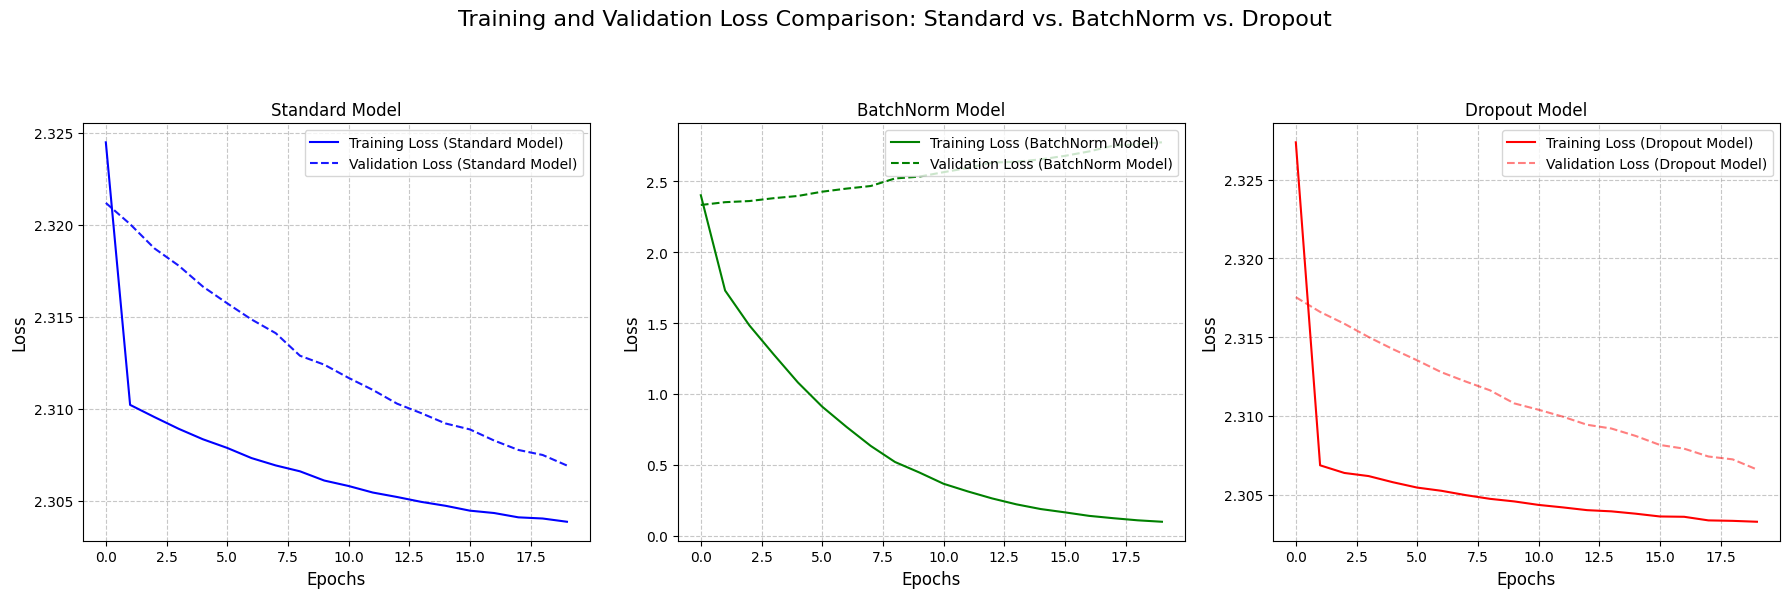

In [39]:
# Initialize a figure and an axes object for plotting
fig, ax = plt.subplots(1,3, figsize=(18, 6))

# Plotting training losses
ax[0].plot(standard_train_loss, label='Training Loss (Standard Model)', color='blue', linestyle='-')
ax[0].plot(standard_val_loss, label='Validation Loss (Standard Model)', color='blue', linestyle='--' , alpha=0.9)
ax[0].set_title('Standard Model')

ax[1].plot(batchnorm_train_loss, label='Training Loss (BatchNorm Model)', color='green', linestyle='-')
ax[1].plot(batchnorm_val_loss, label='Validation Loss (BatchNorm Model)', color='green', linestyle='--')
ax[1].set_title('BatchNorm Model')

ax[2].plot(dropout_train_loss, label='Training Loss (Dropout Model)', color='red', linestyle='-')
ax[2].plot(dropout_val_loss, label='Validation Loss (Dropout Model)', color='red', linestyle='--',  alpha=0.5)
ax[2].set_title('Dropout Model')

# Set common labels and title for the plots
for a in ax:
    a.set_xlabel('Epochs', fontsize=12)
    a.set_ylabel('Loss', fontsize=12)
    a.legend(loc='upper right', fontsize=10)
    a.grid(True, linestyle='--', alpha=0.7)

fig.suptitle('Training and Validation Loss Comparison: Standard vs. BatchNorm vs. Dropout', fontsize=16, y=1.02)

# Adjust layout to prevent labels from being cut off
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle

# Display the plot
plt.show()

- Standard model (neither BatchNorm nor Dropout): Shows the gradual loss convergence.
- Only BatchNorm model: extreme overfitting, the training loss decreased but validation loss started increase from start.
- Only Dropout model: gradual loss decrease, converges lowest loss.

# Part A: Defect Type Classifier


In [14]:
import torch

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Torch Version: {torch.__version__}")

Using device: cuda
Torch Version: 2.11.0+cu128


1. Load the NEU dataset using
torchvision.datasets.ImageFolder and torch.utils.data.DataLoader. How many
images per class? What are the image dimensions?


In [15]:
# Importing datasets from kaggle
import kagglehub
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

train_path = path+'/NEU-DET/train/images'
val_path = path + '/NEU-DET/validation/images'
print(f"Train dataset path: {train_path}")
print(f"Validation dataset path: {val_path}")

100%|██████████| 26.4M/26.4M [00:00<00:00, 225MB/s]

Extracting files...


Train dataset path: /root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET/train/images
Validation dataset path: /root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET/validation/images


In [16]:
from torchvision.datasets import ImageFolder
from collections import Counter

train_dataset = ImageFolder(root = train_path)
val_dataset = ImageFolder(root = val_path)

tarin_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# -- Print --
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Train dataset classes: {train_dataset.classes}")
print(f"Validation dataset classes: {val_dataset.classes}")
print(f"Train dataset target counts: {Counter(train_dataset.targets)}")
print(f"Validation dataset target counts: {Counter(val_dataset.targets)}")

print(f"\nTrain loader length: {len(tarin_loader)}")
print(f"Validation loader length: {len(val_loader)}")

Train dataset size: 1440
Validation dataset size: 360
Train dataset classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Validation dataset classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Train dataset target counts: Counter({0: 240, 1: 240, 2: 240, 3: 240, 4: 240, 5: 240})
Validation dataset target counts: Counter({0: 60, 1: 60, 2: 60, 3: 60, 4: 60, 5: 60})

Train loader length: 45
Validation loader length: 12


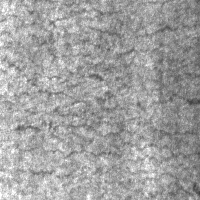

In [17]:
# Peek at first image
train_dataset[0][0]

In [18]:
# Create an iterator from dataset
data_iter = iter(train_dataset)

# Pull the very first batch off the belt
images, labels = next(data_iter)
print(images)
print(labels)
print(f"Image size: {images.size}")

<PIL.Image.Image image mode=RGB size=200x200 at 0x7902832817F0>
0
Image size: (200, 200)


* Image is of size 200 x 200 with 3 channels (RGB) -(without transform)
* Train dataset count 1440, Validation dataset count 360.
* Total of 6 target class. 240 images per class in Train set and 60 images per class in Val set.
* With batches of 32 in dataloader, total lenth of train loader is 45 and val loader is 12.
* Images are not yet transformed into tensors.


2. Normalise pixel values using
torchvision.transforms.Normalize. Why is normalisation important before training
a CNN?

> Normalization is necessary to make uniform image pixel sizes.
> Pytorch tensors expects numbers on those grids instead of pictures. Normalizing tensors number with mean of 0.5 and std of 0.5 to make sure the range stays same in all differnt batches e.g., if batch 1 and 2 has different metrics/ mean std then model might be unstable or not generalize well.

In [19]:
# Using the path for train and val from above.
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((32,32)), # all image same size
    transforms.ToTensor(),  # iamge to tensors
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = ImageFolder(root = train_path, transform=transform)
val_dataset = ImageFolder(root = val_path, transform=transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\nTrain loader length: {len(train_loader)}")
print(f"Validation loader length: {len(val_loader)}")

train_iter = iter(train_loader)
val_iter = iter(val_loader)

train_batch = next(train_iter)
val_batch = next(val_iter)

print(f"Train batch size: {train_batch[0].size()}")
print(f"Validation batch size: {val_batch[0].size()}")

Train dataset size: 1440
Validation dataset size: 360

Train loader length: 45
Validation loader length: 12
Train batch size: torch.Size([32, 3, 32, 32])
Validation batch size: torch.Size([32, 3, 32, 32])


The images are now set to train with 32 batch size, 3 channels and 32x32 size.

3.    Build a CNN classifier using nn.Module with at least:
    Conv2d → ReLU → MaxPool2d (×2) → Flatten → Linear output for 6 classes.

4.    Write a full PyTorch training loop:
    zero_grad() → forward() → CrossEntropyLoss → backward() → optimizer.step(). Train for 15 epochs.

In [20]:
import torch.nn.functional as F
import torch

class ClassifierCNN(nn.Module):
    def __init__(self,INPUT_SIZE=(3,32,32), no_of_classes=6):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)

        # ---- Used this as debugging the image flatten size -----
        # Calculate flattened size dynamically
        # dummy = torch.zeros(1, *INPUT_SIZE) # Create a dummy input tensor
        # x = self.pool(F.relu(self.conv1(dummy))) # Apply first conv, relu, and pool
        # x = self.pool(F.relu(self.conv2(x))) # Apply second conv, relu, and pool
        # flattened_size = x.view(1, -1).shape[1] # Flatten and get the size
        # print(f"DEBUG: Calculated flattened size: {flattened_size}") # Print for verification

        self.linear1 = nn.Linear(8*8*8, 64) #
        """ Original image 32,32 size.
         - kernel size 3, with padding 1 this preserves spatial dimensions
         - used MaxPool2d this reduce the dimension by half
         - image size after convolution and 2 * max pool = 32 / 2 * 2 = 8,8 size
         - conv2 returns 16 batch, 8 channels, 8,8 image size = 8*8*8
        """
        self.linear2 = nn.Linear(64, no_of_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        return x

    def train_and_evaluate(self, train_loader, val_loader):
        no_of_epoch = 15
        train_losses = []
        val_losses = []

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.parameters(), lr=0.001)

        # Training
        for epoch in range(no_of_epoch):
            self.train()
            train_epoch_loss = 0.0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                output = self(inputs)
                loss = criterion(output, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_epoch_loss += loss.item() * inputs.size(0)
            train_epoch_loss /= len(train_loader.dataset)
            train_losses.append(train_epoch_loss)

            # Validation
            self.eval()
            val_epoch_loss = 0.0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    output = self(inputs)
                    loss = criterion(output, labels)

                    val_epoch_loss += loss.item() * inputs.size(0)
            val_epoch_loss /= len(val_loader.dataset)
            val_losses.append(val_epoch_loss)
            print(f"Epoch {epoch+1}/{no_of_epoch}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
        return train_losses, val_losses

model = ClassifierCNN()
model.to(device)
train_losses, val_losses = model.train_and_evaluate(train_loader, val_loader)

Epoch 1/15, Train Loss: 1.5407, Val Loss: 1.6233
Epoch 2/15, Train Loss: 1.2498, Val Loss: 1.4454
Epoch 3/15, Train Loss: 1.0061, Val Loss: 1.2938
Epoch 4/15, Train Loss: 0.8226, Val Loss: 1.4772
Epoch 5/15, Train Loss: 0.7613, Val Loss: 1.1167
Epoch 6/15, Train Loss: 0.6313, Val Loss: 1.1394
Epoch 7/15, Train Loss: 0.5403, Val Loss: 0.9631
Epoch 8/15, Train Loss: 0.5051, Val Loss: 1.0872
Epoch 9/15, Train Loss: 0.4626, Val Loss: 1.2285
Epoch 10/15, Train Loss: 0.4337, Val Loss: 0.9557
Epoch 11/15, Train Loss: 0.4015, Val Loss: 0.8202
Epoch 12/15, Train Loss: 0.3926, Val Loss: 0.6945
Epoch 13/15, Train Loss: 0.3438, Val Loss: 0.8334
Epoch 14/15, Train Loss: 0.3274, Val Loss: 1.0175
Epoch 15/15, Train Loss: 0.3287, Val Loss: 0.7466


5.    Plot training vs. validation accuracy and loss. Is the model overfitting? At what epoch does it start?

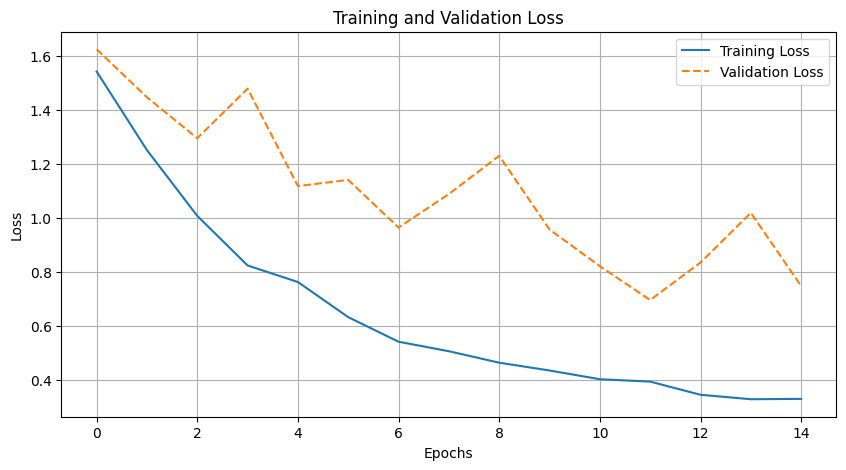

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Training Loss')
ax.plot(val_losses, label='Validation Loss', linestyle='--')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
plt.grid(True)
plt.show()

-- Highly overfitted model --
- High difference in train loss (0.3824) and val loss (0.7466)
- The fluctuation on validation loss is started from epoch 3 (counting from 0), but model shows the ability to learn and the fluctuation is less.
- after epoch 8, the model has completely memorized the dataset and a big jump in increasing the val loss from 0.64 to 0.93.

6.    Per-class evaluation: which defect type has the lowest F1 score on the test set? Look at misclassified examples — why might crazing and patches be confused?

In [22]:
# evaluation state
model.eval()
all_labels = []
all_predictions = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        output = model(inputs)

        _ , predicted = torch.max(output.data , dim =1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

report_classificaion = classification_report(all_labels, all_predictions, target_names=val_dataset.classes)
print("-- Baseline modlels classification report --")
print(report_classificaion)
flscore = f1_score(all_labels, all_predictions, average='weighted')
print(f"Weighted F1 Score: {flscore}")

-- Baseline modlels classification report --
                 precision    recall  f1-score   support

        crazing       0.85      1.00      0.92        60
      inclusion       0.40      0.48      0.44        60
        patches       0.97      1.00      0.98        60
 pitted_surface       0.71      0.82      0.76        60
rolled-in_scale       0.57      0.42      0.48        60
      scratches       0.88      0.60      0.71        60

       accuracy                           0.72       360
      macro avg       0.73      0.72      0.71       360
   weighted avg       0.73      0.72      0.71       360

Weighted F1 Score: 0.7148429596117779


Regarding the confusion between crazing and patches, visually, both defect types can present as irregular patterns on the surface of the material. Crazing often appears as a network of fine cracks, while patches might be localized areas of discoloration, foreign material, or surface irregularities. Depending on the size, density, and texture of these defects, especially in lower-resolution images or under certain lighting conditions, their visual features can overlap, leading the model to misclassify them. The model might struggle to distinguish between a tight network of crazing and a clustered patch of defects.

> In this Classification report, The lowest f1-score obtained by inclusion. scratches and rolled-in_scale are also low in f1-score. For crazing and patches model shows good f1 score.
>
> overall weighted f1 scores is balanced at 0.71.

Total misclassified examples: 101 out of: 360


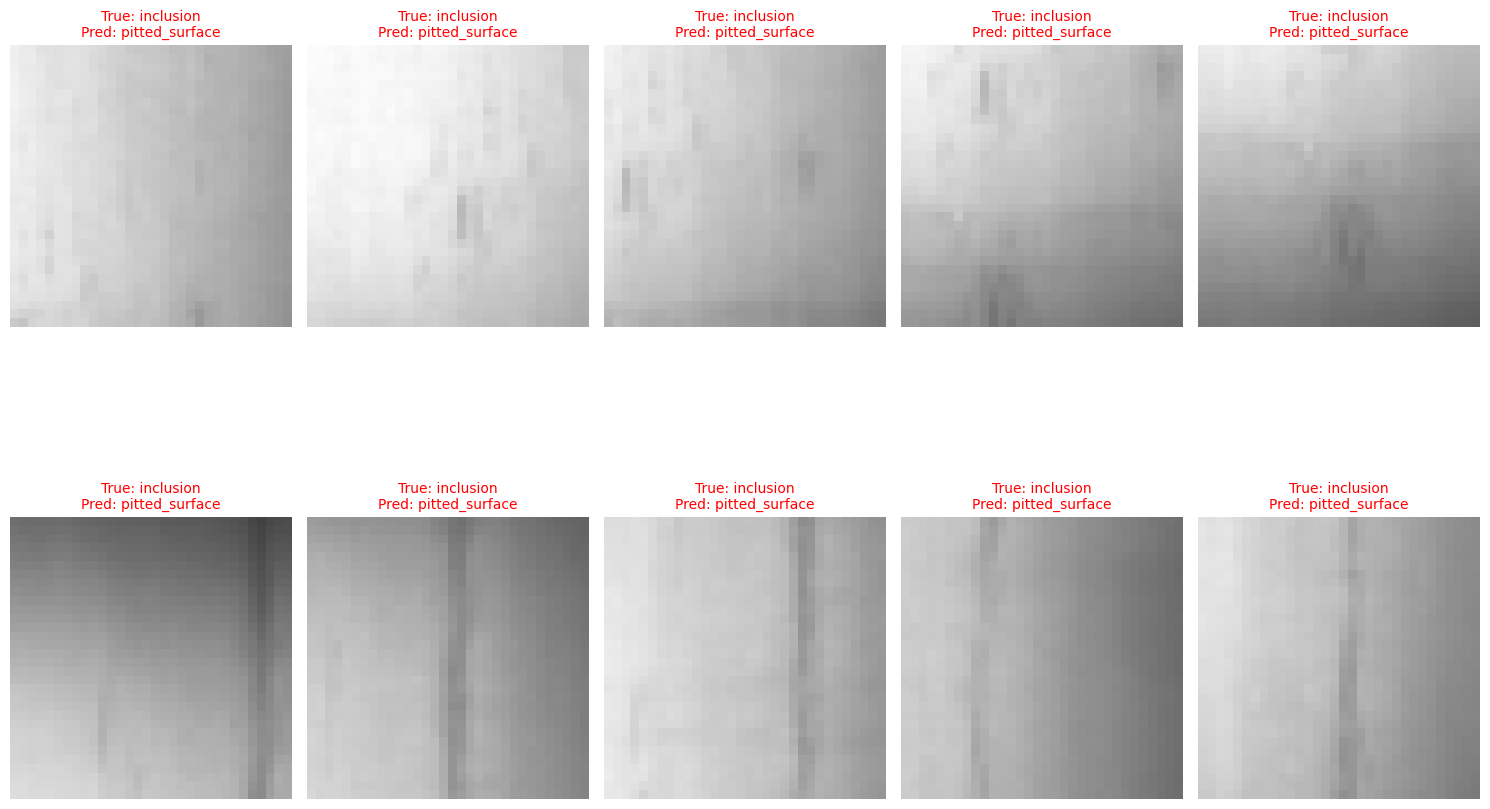

In [23]:
# Get class names from the dataset
class_names = val_dataset.classes

# Find misclassified indices
misclassified_indices = [i for i in range(len(all_labels)) if all_labels[i] != all_predictions[i]]

print(f"Total misclassified examples: {len(misclassified_indices)} out of: {len(all_labels)}")

# Function to denormalize image for display
def denormalize_image(tensor_image):
    # Assumes normalization mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]
    denorm_image = tensor_image * 0.5 + 0.5
    return denorm_image.clamp(0, 1) # Ensure pixel values are between 0 and 1

# Display some misclassified examples
num_display = min(10, len(misclassified_indices)) # Display up to 10 misclassified images
fig = plt.figure(figsize=(15, 5 * (num_display // 5 + 1)))

for i, idx in enumerate(misclassified_indices[:num_display]):
    # Get the original image (tensor) and its true/predicted labels
    image_tensor, true_label_idx = val_dataset[idx]
    predicted_label_idx = all_predictions[idx]

    # Denormalize and permute dimensions for matplotlib (C, H, W) -> (H, W, C)
    image_to_display = denormalize_image(image_tensor).permute(1, 2, 0)

    ax = fig.add_subplot(num_display // 5 + 1, 5, i + 1)
    ax.imshow(image_to_display.cpu().numpy())
    ax.set_title(f"True: {class_names[true_label_idx]}\nPred: {class_names[predicted_label_idx]}", fontsize=10, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

From the plot,
> Inclusion are mostly predicted as pitted_surface.
>
> Crazing predicted as rolled-in_scale.
>
> Also a sign of crazing predicted as patches.

# Part B: Model Hardening


7.    Data augmentation: add transforms for the training set only — RandomHorizontalFlip, RandomRotation(15), RandomCrop(180). Do NOT augment the validation/test set. Why?
> The validation set are supposed to be kept the original only and the type of images that resembels which might appear  during deployment. The train set are only augmented so that model doesnt learn the noise, or color area etc. and instead it focuses on learning the pattern.

In [24]:
# Data augumentation

train_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    # transforms.RandomCrop(180), Not using crop as the image size is set to 32,32
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # added for colors as well!
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = ImageFolder(root = train_path, transform=train_transform)
val_dataset = ImageFolder(root = val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
print(f"--Data Augumented -- ")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

print(f"\nTrain loader length: {len(train_loader)}")
print(f"Validation loader length: {len(val_loader)}")

--Data Augumented -- 
Train dataset size: 1440
Validation dataset size: 360

Train loader length: 45
Validation loader length: 12


8.   Batch normalisation: add nn.BatchNorm2d after each
Conv2d layer. Retrain.
9.  Dropout: add nn.Dropout(0.4) before the final Linear
layer.
10.  Plot
all three configurations (Part A baseline, +augmentation,
+augmentation+BN+dropout) on the same validation accuracy graph.

In [25]:
class LinearAugumentedClassifierCNN(nn.Module):
    def __init__(self,INPUT_SIZE=(3,32,32), no_of_classes=6, is_batchnorm=False, is_dropout=False):
        super().__init__()
        self.conv1 = nn.Conv2d(3,16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16,8, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(8)
        self.linear1 = nn.Linear(8*8*8, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.linear2 = nn.Linear(64, no_of_classes)
        self.dropout = nn.Dropout(0.4)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2)
        self.is_batchnorm = is_batchnorm
        self.is_dropout = is_dropout

    def forward(self, x):
        x = self.conv1(x)
        if self.is_batchnorm:
            x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        if self.is_batchnorm:
            x = self.bn2(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = torch.flatten(x, 1)
        x = self.linear1(x)
        if self.is_batchnorm:
            x = self.bn3(x)
        x = self.relu(x)
        if self.is_dropout:
            x = self.dropout(x)
        x = self.linear2(x)
        return x
model1 = LinearAugumentedClassifierCNN()
model1= model1.to(device)
print(model1)


LinearAugumentedClassifierCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear1): Linear(in_features=512, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear2): Linear(in_features=64, out_features=6, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


 -- Augmented Model training -- 
 -- BatchNorm + Augmented Model training -- 
 -- Dropout + Augmented Model training -- 
 -- BatchNorm + Dropout + Augmented Model training -- 


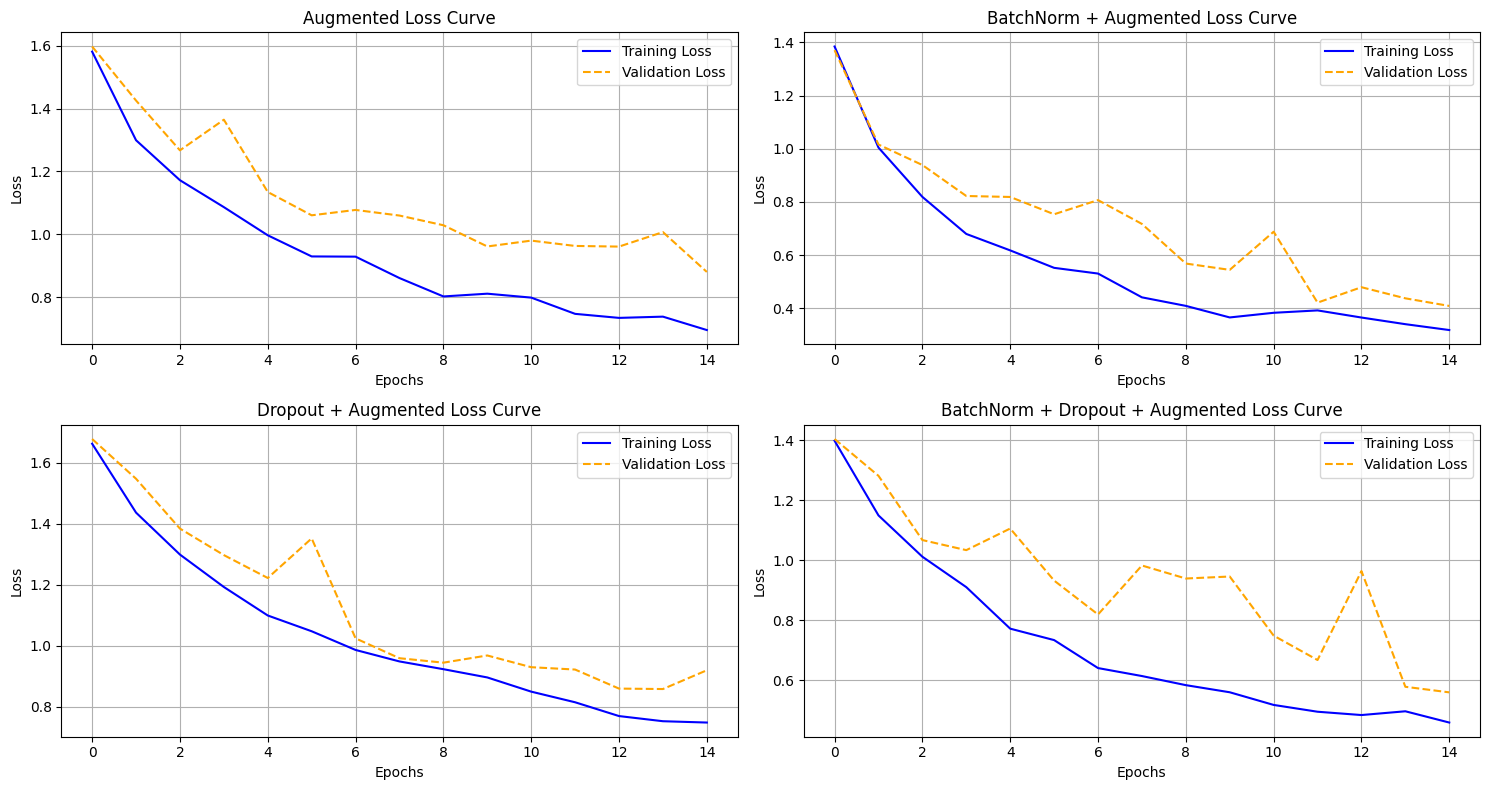

In [26]:
from collections import OrderedDict
import torch.nn as nn
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

class SequentialClassifier(nn.Module):
    """
    A Sequential Convolutional Neural Network (CNN) classifier.

    This class demonstrates how to define a neural network architecture
    using nn.Sequential with an OrderedDict for structured layer definition.
    It includes optional Batch Normalization and Dropout layers for
    regularization and improved training stability.
    """
    def __init__(self, input_size=(3,32,32), num_classes=6, is_batchnorm=False, is_dropout=False):
        super().__init__()

        # --- Feature Extraction (Convolutional and Pooling Layers) ---
        # Defines the feature extraction part of the CNN using a Sequential module.
        # OrderedDict is used to give names to layers, which can be useful for debugging and introspection.
        self.features = nn.Sequential(OrderedDict([
            ('conv1', nn.Conv2d(input_size[0], 16, kernel_size=3, padding=1)),
            # Batch Normalization after Conv2d, before activation (common practice to stabilize training)
            ('bn1', nn.BatchNorm2d(16) if is_batchnorm else nn.Identity()),
            ('relu1', nn.ReLU()),
            ('maxpool1', nn.MaxPool2d(2)), # Reduces spatial dimensions by half (e.g., 32x32 -> 16x16)

            ('conv2', nn.Conv2d(16, 8, kernel_size=3, padding=1)),
            # Batch Normalization after Conv2d, before activation
            ('bn2', nn.BatchNorm2d(8) if is_batchnorm else nn.Identity()),
            ('relu2', nn.ReLU()),
            ('maxpool2', nn.MaxPool2d(2))  # Reduces spatial dimensions by half (e.g., 16x16 -> 8x8)
        ]))

        # Calculate the flattened size after convolutional and pooling layers.
        # For a (3,32,32) input with two MaxPool2d(2) layers, the spatial dimensions become 8x8.
        # The last conv layer ('conv2') outputs 8 channels.
        # So, the flattened size will be 8 (channels) * 8 (height) * 8 (width) = 512 features.
        flattened_size = 8 * 8 * 8 # This value is specific to the defined architecture and input_size.

        # --- Classification Head (Fully Connected Layers) ---
        # Defines the classification part of the CNN.
        self.classifier = nn.Sequential(OrderedDict([
            ('flatten', nn.Flatten()), # Flattens the output of the features module into a 1D vector.
            ('linear1', nn.Linear(flattened_size, 64)),
            # Batch Normalization for 1D features after a Linear layer.
            ('bn3', nn.BatchNorm1d(64) if is_batchnorm else nn.Identity()),
            ('relu3', nn.ReLU()),

            # Dropout layer for regularization, applied before the final classification layer.
            # Helps prevent overfitting by randomly setting a fraction of input units to 0 at each update during training.
            ('dropout', nn.Dropout(0.4) if is_dropout else nn.Identity()),

            ('linear2', nn.Linear(64, num_classes)) # Final output layer for classification.
        ]))

        # Combine the feature extraction and classification head into a single sequential model.
        self.ordered_sequential = nn.Sequential(self.features, self.classifier)


    def forward(self, x):
        """
        Defines the forward pass of the model.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor after passing through the network.
        """
        return self.ordered_sequential(x)


    def train_and_evaluate(self, train_loader, val_loader, criterion, optimizer):
        """
        Trains and evaluates the model over a specified number of epochs.

        Args:
            train_loader (torch.utils.data.DataLoader): DataLoader for training data.
            val_loader (torch.utils.data.DataLoader): DataLoader for validation data.
            criterion (torch.nn.modules.loss._Loss): The loss function (e.g., nn.CrossEntropyLoss).
            optimizer (torch.optim.Optimizer): The optimizer for training (e.g., optim.Adam).

        Returns:
            tuple: A tuple containing lists of training losses and validation losses per epoch.
        """
        num_epochs = 15
        train_losses = []
        val_losses = []

        for epoch in range(num_epochs):
            # --- Training Phase ---
            self.train() # Set model to training mode (enables dropout, batchnorm tracking of running statistics)
            train_epoch_loss = 0.0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass: compute predicted outputs
                output = self(inputs)
                # Calculate the batch loss
                loss = criterion(output, labels)

                # Backward and optimize
                optimizer.zero_grad() # Clear previously calculated gradients
                loss.backward()       # Compute gradients of the loss w.r.t. model parameters
                optimizer.step()      # Update model parameters using the computed gradients

                train_epoch_loss += loss.item() * inputs.size(0) # Accumulate weighted loss for the epoch
            train_epoch_loss /= len(train_loader.dataset) # Calculate average training loss for the epoch
            train_losses.append(train_epoch_loss)

            # --- Validation Phase ---
            self.eval() # Set model to evaluation mode (disables dropout, uses fixed running stats for batchnorm)
            val_epoch_loss = 0.0
            with torch.no_grad(): # Disable gradient calculation to save memory and computations during inference
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    # Forward pass
                    output = self(inputs)
                    # Calculate the batch loss
                    loss = criterion(output, labels)

                    val_epoch_loss += loss.item() * inputs.size(0) # Accumulate weighted loss for the epoch

            val_epoch_loss /= len(val_loader.dataset) # Calculate average validation loss for the epoch
            val_losses.append(val_epoch_loss)

            # Optional: print epoch-wise loss for monitoring training progress
            # print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}")
        return train_losses, val_losses

# --- Model Instantiation and Training for Comparison ---
# The following code demonstrates training different configurations of the SequentialClassifier.

# 1. Model with only Data Augmentation (Baseline for this section)
augumented_model = SequentialClassifier(
    input_size=(3,32,32), num_classes=6, is_batchnorm=False, is_dropout=False
)
augumented_model = augumented_model.to(device)
print(" -- Augmented Model training -- ")
augumented_train_losses, val_losses = augumented_model.train_and_evaluate(
    train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(augumented_model.parameters(), lr=0.001)
)

# 2. Model with Batch Normalization + Data Augmentation
bn_augumented_model = SequentialClassifier(
    input_size=(3,32,32), num_classes=6, is_batchnorm=True, is_dropout=False
)
bn_augumented_model = bn_augumented_model.to(device)
print(f" -- BatchNorm + Augmented Model training -- ")
bn_augumented_train_losses, bn_val_losses = bn_augumented_model.train_and_evaluate(
    train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(bn_augumented_model.parameters(), lr=0.001)
)

# 3. Model with Dropout + Data Augmentation
dropout_augumented_model = SequentialClassifier(
    input_size=(3,32,32), num_classes=6, is_batchnorm=False, is_dropout=True
)
dropout_augumented_model = dropout_augumented_model.to(device)
print(f" -- Dropout + Augmented Model training -- ")
dropout_augumented_train_losses, dropout_val_losses = dropout_augumented_model.train_and_evaluate(
    train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(dropout_augumented_model.parameters(), lr=0.001)
)

# 4. Model with Batch Normalization + Dropout + Data Augmentation
bn_dropout_augumented_model = SequentialClassifier(
    input_size=(3,32,32), num_classes=6, is_batchnorm=True, is_dropout=True
)
bn_dropout_augumented_model = bn_dropout_augumented_model.to(device)
print(f" -- BatchNorm + Dropout + Augmented Model training -- ")
bn_dropout_augumented_train_losses, bn_dropout_val_losses = bn_dropout_augumented_model.train_and_evaluate(
    train_loader, val_loader, nn.CrossEntropyLoss(), optim.Adam(bn_dropout_augumented_model.parameters(), lr=0.001)
)


# --- Visualization of Training and Validation Losses ---
# This section plots the training and validation loss curves for all four model configurations.

fig, axes = plt.subplots(2, 2, figsize=(15,8)) # Create a 2x2 grid of subplots

# Define the configurations for plotting training losses
plot_train_configs = [
    (augumented_train_losses, val_losses, 'Augmented'),
    (bn_augumented_train_losses, bn_val_losses, 'BatchNorm + Augmented'),
    (dropout_augumented_train_losses, dropout_val_losses, 'Dropout + Augmented'),
    (bn_dropout_augumented_train_losses, bn_dropout_val_losses, 'BatchNorm + Dropout + Augmented')
]

# Iterate through the configurations and plot on respective subplots
for i, (train_l, val_l, model_name) in enumerate(plot_train_configs):
    r, c = i // 2, i % 2 # Calculate row and column for the current subplot

    # Plot Training Loss
    axes[r, c].plot(train_l, label='Training Loss', color='blue')
    # Plot Validation Loss on the same subplot for easy comparison
    axes[r, c].plot(val_l, label='Validation Loss', linestyle='--', color='orange')

    axes[r, c].set_xlabel('Epochs')
    axes[r, c].set_ylabel('Loss')
    axes[r, c].set_title(f'{model_name} Loss Curve')
    axes[r, c].legend()
    axes[r, c].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the plot

11.  Reflection: if you could only apply one technique from this part to a new manufacturing dataset, which would you choose and why?

**Augumented (baseline)loss curve**
- A higher gap between train and validation loss
- loss converge on same downward with train.

**BatchNorm + Augumented loss curve**
- Overall lowest loss differences.
- Slight fluctuations in middle, but converges downward, showing model is generalizing well and better than basline.

**Dropout + Aug**
- Slight rise once but the model learns and geralizes well
- on same downward loss convergence with training.
- slightly higher overall loss than batchnorm.

**Batchnorm + dropout + aug**
- Val loss fluctuations in middle
- Overall downward loss convergence and reaches second lowest  loss at end.

BatchNorm and BachNorm + Dropout both shows the ability to generalize the model well and converge to the lowest loss.
I would go with `BatchNorm + Dropout` using both regularization techniques for better model generalizaiton.

# Part C: Hyperparameter Tuning


12.  Grid search: train your best model from Part B with all combinations of learning
rate in {0.001, 0.01} and batch size in {16, 32}. Record validation accuracy
for each of the 4 combinations.

In [28]:
from sklearn.metrics import f1_score
import copy

# Modify the train_and_evaluate function to accept batch_size and lr
class SequentialClassifierGridSearch(nn.Module):
    def __init__(self, INPUT_SIZE=(3,32,32), no_of_classes=6, is_batchnorm=False, is_dropout=False):
        super().__init__()

        self.ordered_sequential = nn.Sequential(OrderedDict([
            ('conv1', nn.Conv2d(3, 16, kernel_size=3, padding=1)),
            ('bn1', nn.BatchNorm2d(16) if is_batchnorm else nn.Identity()),
            ('relu1', nn.ReLU()),
            ('maxpool1', nn.MaxPool2d(2)),
            ('conv2', nn.Conv2d(16, 8, kernel_size=3, padding=1)),
            ('bn2', nn.BatchNorm2d(8) if is_batchnorm else nn.Identity()),
            ('relu2', nn.ReLU()),
            ('maxpool2', nn.MaxPool2d(2)),
            ('flatten', nn.Flatten()),
            ('linear1', nn.Linear(8*8*8, 64)),
            ('bn3', nn.BatchNorm1d(64) if is_batchnorm else nn.Identity()),
            ('relu3', nn.ReLU()),
            ('dropout', nn.Dropout(0.4) if is_dropout else nn.Identity()),
            ('linear2', nn.Linear(64, no_of_classes))
        ]))

    def forward(self, x):
        return self.ordered_sequential(x)

    def train_and_evaluate_grid(self, train_loader_fn, val_loader_fn, criterion, optimizer_class, lr, num_epochs=15):
        # Create new DataLoaders for each run, so batch_size can vary
        train_loader = train_loader_fn()
        val_loader = val_loader_fn()

        optimizer = optimizer_class(self.parameters(), lr=lr)

        train_losses = []
        val_losses = []

        best_val_f1 = -1
        best_model_state = None

        for epoch in range(num_epochs):
            self.train()
            train_epoch_loss = 0.0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                output = self(inputs)
                loss = criterion(output, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_epoch_loss += loss.item() * inputs.size(0)
            train_epoch_loss /= len(train_loader.dataset)
            train_losses.append(train_epoch_loss)

            self.eval()
            val_epoch_loss = 0.0
            all_val_labels = []
            all_val_predictions = []

            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    output = self(inputs)
                    loss = criterion(output, labels)

                    val_epoch_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(output.data, 1)
                    all_val_labels.extend(labels.cpu().numpy())
                    all_val_predictions.extend(predicted.cpu().numpy())

            val_epoch_loss /= len(val_loader.dataset)
            val_losses.append(val_epoch_loss)

            current_val_f1 = f1_score(all_val_labels, all_val_predictions, average='weighted')

            if current_val_f1 > best_val_f1:
                best_val_f1 = current_val_f1
                # Save the best model state dictionary
                best_model_state = copy.deepcopy(self.state_dict())

        return train_losses, val_losses, best_val_f1, best_model_state

# Define functions to create DataLoaders with variable batch sizes
def create_train_loader(batch_size_arg):
    return DataLoader(train_dataset, batch_size=batch_size_arg, shuffle=True)

def create_val_loader(batch_size_arg):
    return DataLoader(val_dataset, batch_size=batch_size_arg, shuffle=False)


In [29]:
# Define the hyperparameter grid
lr_options = [0.001, 0.0005, 0.0001]
batch_size_options = [16, 32, 64]

# Store results
results = []
best_f1 = -1
best_hyperparams = None
best_model_state_final = None

print("Starting Grid Search...")

for lr in lr_options:
    for batch_size in batch_size_options:
        print(f"\nTraining with LR: {lr}, Batch Size: {batch_size}")

        # Instantiate a fresh model for each run
        model_gs = SequentialClassifierGridSearch(is_batchnorm=True, is_dropout=False) # Using best regularization from Part B
        model_gs.to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer_class = optim.Adam

        # Train and evaluate the model
        train_losses, val_losses, current_f1, current_model_state = model_gs.train_and_evaluate_grid(
            lambda: create_train_loader(batch_size),
            lambda: create_val_loader(batch_size),
            criterion,
            optimizer_class,
            lr
        )

        results.append({
            'lr': lr,
            'batch_size': batch_size,
            'final_val_loss': val_losses[-1],
            'best_val_f1': current_f1,
            'train_losses': train_losses,
            'val_losses': val_losses
        })

        print(f"LR: {lr}, Batch Size: {batch_size}, Best Val F1: {current_f1:.4f}")

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_hyperparams = {'lr': lr, 'batch_size': batch_size}
            best_model_state_final = current_model_state

print("\nGrid Search Complete.")
print(f"Best Hyperparameters: {best_hyperparams}")
print(f"Best Validation F1 Score: {best_f1:.4f}")

Starting Grid Search...

Training with LR: 0.001, Batch Size: 16
LR: 0.001, Batch Size: 16, Best Val F1: 0.8705

Training with LR: 0.001, Batch Size: 32
LR: 0.001, Batch Size: 32, Best Val F1: 0.8634

Training with LR: 0.001, Batch Size: 64
LR: 0.001, Batch Size: 64, Best Val F1: 0.8614

Training with LR: 0.0005, Batch Size: 16
LR: 0.0005, Batch Size: 16, Best Val F1: 0.8169

Training with LR: 0.0005, Batch Size: 32
LR: 0.0005, Batch Size: 32, Best Val F1: 0.8373

Training with LR: 0.0005, Batch Size: 64
LR: 0.0005, Batch Size: 64, Best Val F1: 0.7326

Training with LR: 0.0001, Batch Size: 16
LR: 0.0001, Batch Size: 16, Best Val F1: 0.7072

Training with LR: 0.0001, Batch Size: 32
LR: 0.0001, Batch Size: 32, Best Val F1: 0.6089

Training with LR: 0.0001, Batch Size: 64
LR: 0.0001, Batch Size: 64, Best Val F1: 0.5584

Grid Search Complete.
Best Hyperparameters: {'lr': 0.001, 'batch_size': 16}
Best Validation F1 Score: 0.8705


13. Present results as a markdown table. Which combination performed best? Which hyperparameter had more impact?

| Learning Rate | Batch Size | Best Validation F1 Score |
|---------------|------------|--------------------------|
| 0.001         | 16         | 0.8705                   |
| 0.001         | 32         | 0.8634                   |
| 0.001         | 64         | 0.8614                   |
| 0.0005        | 16         | 0.8169                   |
| 0.0005        | 32         | 0.8373                   |
| 0.0005        | 64         | 0.7326                   |
| 0.0001        | 16         | 0.7072                   |
| 0.0001        | 32         | 0.6089                   |
| 0.0001        | 64         | 0.5584                   |

**Grid Search Analysis:**

The best performing combination yielded a **Best Validation F1 Score of 0.8705** with **Learning Rate: 0.001** and **Batch Size: 16**.

Analyzing the impact of each hyperparameter:

*   **Learning Rate:** The learning rate appears to have a more significant impact on the model's performance. A higher learning rate (0.001) consistently resulted in much higher F1 scores across different batch sizes compared to lower learning rates (0.0005 and 0.0001). As the learning rate decreased, the F1 scores dropped considerably.

*   **Batch Size:** While batch size also influenced the F1 score, its impact was less pronounced than that of the learning rate within the tested ranges. For the optimal learning rate of 0.001, a batch size of 16 performed best, followed closely by 32 and 64. However, the performance degradation for batch size was less steep than for learning rate, especially at the higher learning rates.

**Conclusion:** In this grid search, **learning rate had a more substantial impact** on the model's validation F1 score than the batch size. Optimizing the learning rate was crucial for achieving better performance.

In [30]:
# Optional: Load the best model state for later use
# best_model = SequentialClassifierGridSearch(is_batchnorm=True, is_dropout=True)
# best_model.load_state_dict(best_model_state_final)
# best_model.to(device)

15.  Extended
— Bayesian optimisation: use Optuna to search over lr (1e-4 to 1e-1,
log-uniform) and batch size (8 to 64). Does it find a better combination than
your grid search?

In [32]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.0 MB/s eta 0:00:00


Starting Optuna hyperparameter optimization...


[I 2026-07-12 08:29:27,059] A new study created in RDB with name: cnn_hpo_fresh
[I 2026-07-12 08:29:51,393] Trial 0 finished with value: 0.7514134458745414 and parameters: {'learning_rate': 0.001974512244657298, 'batch_size': 16, 'is_batchnorm': True, 'is_dropout': True, 'dropout_rate': 0.2, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.7514134458745414.
[I 2026-07-12 08:30:05,318] Trial 1 finished with value: 0.6480975249607209 and parameters: {'learning_rate': 0.006097418264248942, 'batch_size': 16, 'is_batchnorm': False, 'is_dropout': False, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.7514134458745414.
[I 2026-07-12 08:30:19,900] Trial 2 finished with value: 0.5194345741339421 and parameters: {'learning_rate': 0.0035208314499298736, 'batch_size': 8, 'is_batchnorm': False, 'is_dropout': True, 'dropout_rate': 0.2, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.7514134458745414.
[I 2026-07-12 08:30:34,378] Trial 3 finished with value: 0.5603669492988378 and parameter


Optuna study complete.
Best trial:
  Value (Best Validation F1 Score): 0.7514
  Params: {'learning_rate': 0.001974512244657298, 'batch_size': 16, 'is_batchnorm': True, 'is_dropout': True, 'dropout_rate': 0.2, 'optimizer': 'Adam'}

Performing full training on top 3 candidates...

--- Full training for Top Candidate 1 (Trial 0) ---
  Optuna Trial Value: 0.7514
  Hyperparameters: {'learning_rate': 0.001974512244657298, 'batch_size': 16, 'is_batchnorm': True, 'is_dropout': True, 'dropout_rate': 0.2, 'optimizer': 'Adam'}
  Full Training Final F1 Score: 0.8595

--- Full training for Top Candidate 2 (Trial 23) ---
  Optuna Trial Value: 0.7255
  Hyperparameters: {'learning_rate': 0.0008925584516141317, 'batch_size': 16, 'is_batchnorm': True, 'is_dropout': False, 'optimizer': 'Adam'}
  Full Training Final F1 Score: 0.8877

--- Full training for Top Candidate 3 (Trial 14) ---
  Optuna Trial Value: 0.7188
  Hyperparameters: {'learning_rate': 0.0013584240647082741, 'batch_size': 32, 'is_batchnorm

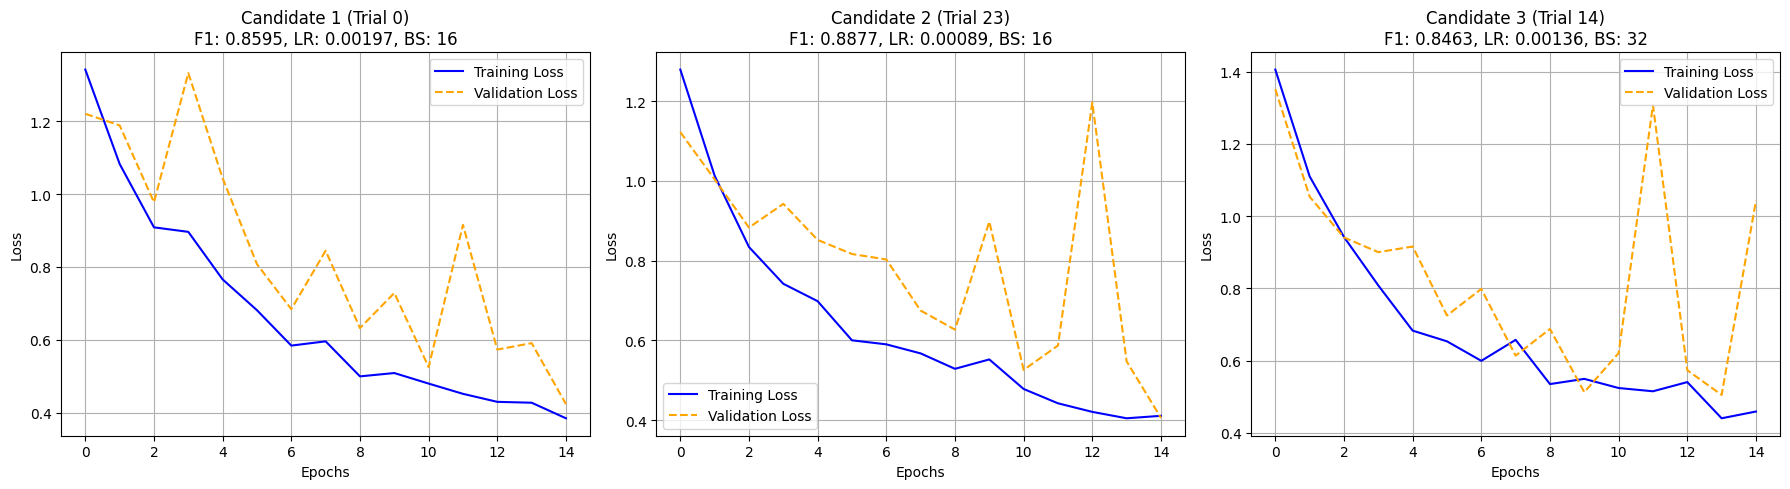


Overall Best Full Training Candidate (based on Final F1 Score):
  Trial Number: 23
  Hyperparameters: {'learning_rate': 0.0008925584516141317, 'batch_size': 16, 'is_batchnorm': True, 'is_dropout': False, 'optimizer': 'Adam'}
  Final F1 Score: 0.8877

Best model from Optuna full training loaded and ready for further evaluation.


In [33]:
import optuna
from collections import OrderedDict
from sklearn.metrics import f1_score
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# Ensure global variables from previous cells are accessible
# train_dataset, val_dataset, device, nn, optim, DataLoader

# --- Step 0: Clean up previous Optuna study if parameter space has changed ---
# This is necessary if you change the search space of an existing study,
# e.g., modifying the choices in `trial.suggest_categorical`.
study_db_path = 'db.sqlite3'
if os.path.exists(study_db_path):
    os.remove(study_db_path)
    print(f"Removed existing Optuna study database: {study_db_path}")

# --- Step 1: Define an Optuna-compatible model and training function ---
# This class is a slightly modified version of the SequentialClassifier from Part B,
# designed to be compatible with Optuna by allowing hyperparameter injection.
class OptunaSequentialClassifier(nn.Module):
    def __init__(self, input_size=(3,32,32), num_classes=6, is_batchnorm=False, is_dropout=False, dropout_rate=0.4):
        super().__init__()

        # Feature extraction layers (Convolutional, BatchNorm, ReLU, MaxPool)
        self.features = nn.Sequential(OrderedDict([
            ('conv1', nn.Conv2d(input_size[0], 16, kernel_size=3, padding=1)),
            ('bn1', nn.BatchNorm2d(16) if is_batchnorm else nn.Identity()), # Optional Batch Normalization
            ('relu1', nn.ReLU()),
            ('maxpool1', nn.MaxPool2d(2)),

            ('conv2', nn.Conv2d(16, 8, kernel_size=3, padding=1)),
            ('bn2', nn.BatchNorm2d(8) if is_batchnorm else nn.Identity()),  # Optional Batch Normalization
            ('relu2', nn.ReLU()),
            ('maxpool2', nn.MaxPool2d(2))
        ]))

        # Calculate the flattened size dynamically based on the convolutions and pooling.
        # For (3,32,32) input, two MaxPool2d(2) reduce spatial dims to 8x8. Last conv has 8 channels.
        flattened_size = 8 * 8 * 8 # 8 channels * 8 height * 8 width

        # Classification head layers (Flatten, Linear, BatchNorm, ReLU, Dropout, Linear)
        self.classifier = nn.Sequential(OrderedDict([
            ('flatten', nn.Flatten()), # Flattens the 3D tensor to a 1D vector
            ('linear1', nn.Linear(flattened_size, 64)),
            ('bn3', nn.BatchNorm1d(64) if is_batchnorm else nn.Identity()), # Optional Batch Normalization
            ('relu3', nn.ReLU()),
            ('dropout', nn.Dropout(dropout_rate) if is_dropout else nn.Identity()), # Optional Dropout
            ('linear2', nn.Linear(64, num_classes)) # Output layer for 6 classes
        ]))

        # Combine feature extractor and classifier into a single sequential model
        self.ordered_sequential = nn.Sequential(self.features, self.classifier)

    def forward(self, x):
        """Forward pass definition."""
        return self.ordered_sequential(x)

    def train_and_evaluate_grid(self, train_loader_fn, val_loader_fn, criterion, optimizer_class, lr, num_epochs=5):
        """
        Trains and evaluates the model, returning performance metrics and the best model state.

        This method creates DataLoaders and an optimizer internally for each run,
        ensuring a fresh start for each hyperparameter combination.

        Args:
            train_loader_fn (function): A function that returns a DataLoader for training.
            val_loader_fn (function): A function that returns a DataLoader for validation.
            criterion (nn.Module): The loss function.
            optimizer_class (torch.optim.Optimizer): The optimizer class (e.g., optim.Adam).
            lr (float): Learning rate for the optimizer.
            num_epochs (int): Number of epochs to train for.

        Returns:
            tuple: (best_val_f1, train_losses, val_losses, best_model_state_dict).
                   best_val_f1: Highest weighted F1 score on the validation set.
                   train_losses: List of training losses per epoch.
                   val_losses: List of validation losses per epoch.
                   best_model_state_dict: State dictionary of the model that achieved best_val_f1.
        """
        # Create new DataLoaders for each run to accommodate varying batch sizes
        train_loader = train_loader_fn()
        val_loader = val_loader_fn()

        model = self.to(device) # Ensure model is on the correct device
        optimizer = optimizer_class(model.parameters(), lr=lr)

        train_losses = []
        val_losses = []

        best_val_f1 = -1.0
        best_model_state = None

        for epoch in range(num_epochs):
            # --- Training Phase ---
            model.train() # Set model to training mode
            train_epoch_loss = 0.0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                output = model(inputs)
                loss = criterion(output, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_epoch_loss += loss.item() * inputs.size(0) # Accumulate loss for batch

            train_epoch_loss /= len(train_loader.dataset) # Average loss for the epoch
            train_losses.append(train_epoch_loss) # Store for plotting

            # --- Validation Phase ---
            model.eval() # Set model to evaluation mode
            val_epoch_loss = 0.0
            all_val_labels = []
            all_val_predictions = []

            with torch.no_grad(): # Disable gradient calculation for validation
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    output = model(inputs)
                    loss = criterion(output, labels) # Calculate loss for validation
                    _, predicted = torch.max(output.data, 1) # Get predicted class
                    all_val_labels.extend(labels.cpu().numpy())
                    all_val_predictions.extend(predicted.cpu().numpy())
                    val_epoch_loss += loss.item() * inputs.size(0) # Accumulate loss

            val_epoch_loss /= len(val_loader.dataset) # Average loss for the epoch
            val_losses.append(val_epoch_loss) # Store for plotting

            # Calculate weighted F1 score for the current validation epoch
            current_val_f1 = f1_score(all_val_labels, all_val_predictions, average='weighted')

            # Save model state if current F1 score is the best so far
            if current_val_f1 > best_val_f1:
                best_val_f1 = current_val_f1
                best_model_state = copy.deepcopy(model.state_dict())

        # Return all relevant metrics and the best model state
        return best_val_f1, train_losses, val_losses, best_model_state

# Helper functions for creating DataLoaders with variable batch sizes and workers for efficiency
def create_train_loader(batch_size_arg):
    return DataLoader(train_dataset, batch_size=batch_size_arg, shuffle=True, num_workers=2, pin_memory=True)

def create_val_loader(batch_size_arg):
    return DataLoader(val_dataset, batch_size=batch_size_arg, shuffle=False, num_workers=2, pin_memory=True)


# --- Step 2: Define the Optuna objective function ---
def objective(trial):
    """
    Optuna objective function to be optimized.
    Defines the search space for hyperparameters and evaluates a model's performance.
    """
    # Clear CUDA cache to manage GPU memory across trials, especially important for many trials
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # --- Define Hyperparameter Search Space ---
    # Learning rate: log-uniform distribution between 1e-4 and 1e-1
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True)
    # Batch size: categorical choices between 8, 16, 32, 64
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])
    # Batch Normalization: boolean choice
    is_batchnorm = trial.suggest_categorical('is_batchnorm', [True, False])
    # Dropout: boolean choice
    is_dropout = trial.suggest_categorical('is_dropout', [True, False])
    dropout_rate = 0.0
    # If dropout is enabled, suggest a dropout rate
    if is_dropout:
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
    # Optimizer: categorical choice (restricted to Adam as per user request)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam'])

    # --- Model Setup ---
    # Instantiate the model with the suggested hyperparameters
    model_opt = OptunaSequentialClassifier(
        is_batchnorm=is_batchnorm,
        is_dropout=is_dropout,
        dropout_rate=dropout_rate
    )
    model_opt.to(device) # Move model to GPU if available

    # Define the loss function
    criterion = nn.CrossEntropyLoss()

    # Select optimizer based on the suggested name
    if optimizer_name == 'Adam':
        optimizer_class = optim.Adam
    else: # Fallback, though 'Adam' is the only option now
        optimizer_class = optim.Adam

    # --- Train and Evaluate for the Trial ---
    # Train for a small number of epochs for quick trials to find promising candidates.
    # The full training on best candidates will use more epochs.
    num_trial_epochs = 5

    # Call the training and evaluation method. We only need the F1 score for Optuna's objective.
    # The method returns 4 values, so we unpack only the first one (best_val_f1).
    val_f1, _, _, _ = model_opt.train_and_evaluate_grid(
        lambda: create_train_loader(batch_size), # Pass loader creation functions
        lambda: create_val_loader(batch_size),
        criterion,
        optimizer_class, # Pass the optimizer class, not an instance
        lr,
        num_trial_epochs
    )

    # Clean up: delete the model and clear CUDA cache to free memory for the next trial
    del model_opt
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return val_f1 # Optuna maximizes this value


# --- Step 3: Run the Optuna study ---
print("Starting Optuna hyperparameter optimization...")
# Create an Optuna study. 'maximize' direction for F1 score.
# Store results in an SQLite database for persistence and easy loading.
study = optuna.create_study(direction='maximize', study_name='cnn_hpo_fresh', storage='sqlite:///db.sqlite3', load_if_exists=True)
# Run the optimization for a specified number of trials
study.optimize(objective, n_trials=30) # You can increase n_trials for a more thorough search

print("\nOptuna study complete.")
print(f"Best trial:")
print(f"  Value (Best Validation F1 Score): {study.best_value:.4f}")
print(f"  Params: {study.best_params}")


# --- Step 4: Full training on best performing candidates ---
print("\nPerforming full training on top 3 candidates...")

# Get the top N trials based on their objective value (F1 score)
num_top_candidates = 3
top_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else -1, reverse=True)[:num_top_candidates]

full_train_results = []

for i, trial in enumerate(top_trials):
    print(f"\n--- Full training for Top Candidate {i+1} (Trial {trial.number}) ---")
    print(f"  Optuna Trial Value: {trial.value:.4f}")
    print(f"  Hyperparameters: {trial.params}")

    # Extract hyperparameters from the trial
    lr = trial.params['learning_rate']
    batch_size = trial.params['batch_size']
    is_batchnorm = trial.params['is_batchnorm']
    is_dropout = trial.params['is_dropout']
    # Use .get() with a default for dropout_rate, as it's only suggested if is_dropout is True
    dropout_rate = trial.params.get('dropout_rate', 0.4)
    optimizer_name = trial.params['optimizer']

    # Clear CUDA cache before instantiating a new model for full training
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Re-instantiate the model with the best hyperparameters
    model_final = OptunaSequentialClassifier(
        is_batchnorm=is_batchnorm,
        is_dropout=is_dropout,
        dropout_rate=dropout_rate
    )
    model_final.to(device) # Move model to device

    criterion = nn.CrossEntropyLoss()

    # Select optimizer class
    if optimizer_name == 'Adam':
        optimizer_class = optim.Adam
    elif optimizer_name == 'SGD':
        optimizer_class = optim.SGD
    else:
        optimizer_class = optim.RMSprop

    # Perform full training for more epochs (e.g., 15, consistent with previous parts)
    num_full_epochs = 15

    # Train and evaluate the model using the optimized hyperparameters
    final_f1, train_losses, val_losses, final_model_state = model_final.train_and_evaluate_grid(
        lambda: create_train_loader(batch_size),
        lambda: create_val_loader(batch_size),
        criterion,
        optimizer_class,
        lr,
        num_full_epochs
    )

    # Store the results of this full training run
    full_train_results.append({
        'trial_number': trial.number,
        'params': trial.params,
        'final_f1': final_f1,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'model_state': final_model_state # Store the best model state from this run
    })

    print(f"  Full Training Final F1 Score: {final_f1:.4f}")

    # Clean up: delete the model and clear CUDA cache
    del model_final
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# --- Step 5: Report and Visualize Full Training Results ---
print("\n--- Full Training Results Summary ---")
best_final_f1_overall = -1.0
best_final_candidate_overall = None

# Create subplots dynamically based on the number of top candidates
fig, axes = plt.subplots(1, len(full_train_results), figsize=(6 * len(full_train_results), 5))
# Ensure 'axes' is always iterable, even for a single subplot
if len(full_train_results) == 1:
    axes = [axes]

for i, res in enumerate(full_train_results):
    ax = axes[i]
    ax.plot(res['train_losses'], label='Training Loss', color='blue')
    ax.plot(res['val_losses'], label='Validation Loss', linestyle='--', color='orange')
    ax.set_title(f"Candidate {i+1} (Trial {res['trial_number']})\nF1: {res['final_f1']:.4f}, LR: {res['params']['learning_rate']:.5f}, BS: {res['params']['batch_size']}")
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

    # Track the overall best performing candidate among the full training runs
    if res['final_f1'] > best_final_f1_overall:
        best_final_f1_overall = res['final_f1']
        best_final_candidate_overall = res

plt.tight_layout() # Adjust layout to prevent overlaps
plt.show()

print(f"\nOverall Best Full Training Candidate (based on Final F1 Score):")
print(f"  Trial Number: {best_final_candidate_overall['trial_number']}")
print(f"  Hyperparameters: {best_final_candidate_overall['params']}")
print(f"  Final F1 Score: {best_final_candidate_overall['final_f1']:.4f}")

# Optionally, load the state dictionary of the best model for later use
best_model_from_optuna = OptunaSequentialClassifier(
    is_batchnorm=best_final_candidate_overall['params']['is_batchnorm'],
    is_dropout=best_final_candidate_overall['params']['is_dropout'],
    dropout_rate=best_final_candidate_overall['params'].get('dropout_rate', 0.4)
)
best_model_from_optuna.load_state_dict(best_final_candidate_overall['model_state'])
best_model_from_optuna.to(device)
print("\nBest model from Optuna full training loaded and ready for further evaluation.")


Surprisingly, the best performing model is with no dropout but in top 3 candidates 2 of them were with dropout.

As seen from before comparision batchnorm + aug, and bachnorm + dropout + aug comparision there also we was the difference in loss convergence was slight to very small.

from grid search the best performing combination yielded a **Best Validation F1 Score of (Grid search) 0.8705** with **Learning Rate: 0.001** and **Batch Size: 16** and **BatchNorm = True** and **Dropout = False.**

With high **F1-score** of `0.8877` obtained from   Hyperparameters:
{'learning_rate': 0.00089, 'batch_size': 16, 'is_batchnorm': True, 'is_dropout': False, 'optimizer': 'Adam'}.


The only difference in hyperparameter in Grid search and Optuna obtained was from `Learning rate`. With less/smaller lr on Adam the best F1-score is obtained.

In [34]:
print("\n--- Classification Report for Best Performing Model ---")
# Ensure best_model_overall is in evaluation mode
best_model_from_optuna.eval()

all_labels_best_model = []
all_predictions_best_model = []

# Create a DataLoader for the validation set using the best batch size found
val_loader_best_bs = create_val_loader(best_final_candidate_overall['params']['batch_size'])

with torch.no_grad():
    for inputs, labels in val_loader_best_bs:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model_from_optuna(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_labels_best_model.extend(labels.cpu().numpy())
        all_predictions_best_model.extend(predicted.cpu().numpy())

# Get class names from the dataset
class_names = val_dataset.classes

report_classificaion_best = classification_report(all_labels_best_model, all_predictions_best_model, target_names=class_names)
print(report_classificaion_best)

f1score_best = f1_score(all_labels_best_model, all_predictions_best_model, average='weighted')
print(f"Weighted F1 Score: {f1score_best:.4f}")


--- Classification Report for Best Performing Model ---
                 precision    recall  f1-score   support

        crazing       0.92      0.98      0.95        60
      inclusion       1.00      0.70      0.82        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.75      0.90      0.82        60
rolled-in_scale       0.78      1.00      0.88        60
      scratches       1.00      0.75      0.86        60

       accuracy                           0.89       360
      macro avg       0.91      0.89      0.89       360
   weighted avg       0.91      0.89      0.89       360

Weighted F1 Score: 0.8877


Previously, as seen in classification report, the f1 score for inclusion and rolled-in scale were lowest. This optimized hyperparameter has obtained balanced weighted f1score along with balanced f1-score for individual class.

In both inclusion and patches, the model is able to  predict them (perfect precision of 1) but not able to find the actual flag (low recall)

In this model, the patches has score of 1 on recall, precision, f1-score i.e., model is able to identify patches correctly (also not assuming patches for others the confusion we had with crazing and patches might be mixed up is cleared for patches).

Overall, this model is genralizing and performing well.

14.  Learning
rate schedule: add torch.optim.lr_scheduler.StepLR (step every 5 epochs,
gamma=0.5) to your best run. Does it improve final test accuracy?


--- Retraining Best Model with Learning Rate Scheduler ---
Epoch 1/15, Current LR: 0.000893, Train Loss: 1.2974, Val Loss: 1.3441, Val F1: 0.4364
Epoch 2/15, Current LR: 0.000893, Train Loss: 1.0690, Val Loss: 1.1371, Val F1: 0.5820
Epoch 3/15, Current LR: 0.000893, Train Loss: 0.9068, Val Loss: 1.0368, Val F1: 0.5759
Epoch 4/15, Current LR: 0.000893, Train Loss: 0.7925, Val Loss: 0.8953, Val F1: 0.6420
Epoch 5/15, Current LR: 0.000446, Train Loss: 0.7197, Val Loss: 0.8569, Val F1: 0.7071
Epoch 6/15, Current LR: 0.000446, Train Loss: 0.6350, Val Loss: 0.8353, Val F1: 0.7309
Epoch 7/15, Current LR: 0.000446, Train Loss: 0.5318, Val Loss: 0.7720, Val F1: 0.7486
Epoch 8/15, Current LR: 0.000446, Train Loss: 0.5201, Val Loss: 0.7875, Val F1: 0.7345
Epoch 9/15, Current LR: 0.000446, Train Loss: 0.5148, Val Loss: 0.7715, Val F1: 0.7506
Epoch 10/15, Current LR: 0.000223, Train Loss: 0.4457, Val Loss: 0.5699, Val F1: 0.7928
Epoch 11/15, Current LR: 0.000223, Train Loss: 0.4345, Val Loss: 0.75

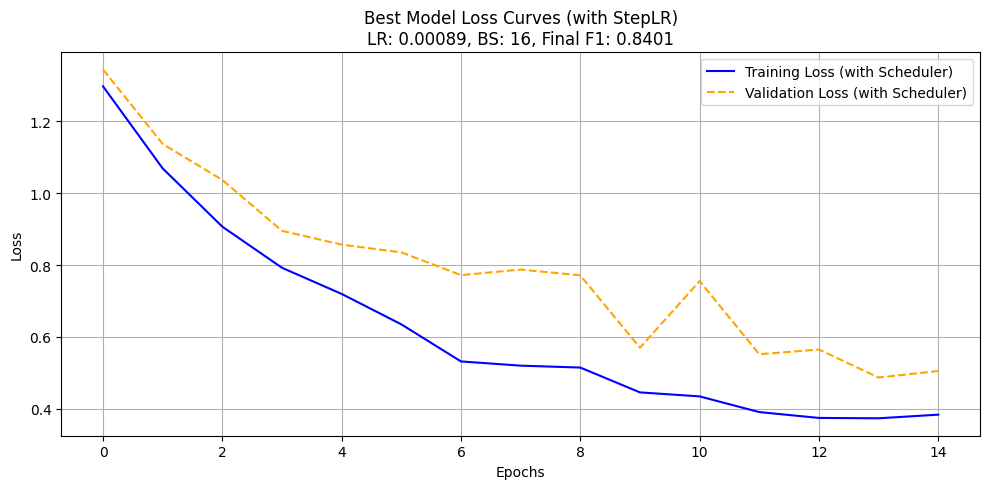


--- Classification Report for Best Model with Scheduler ---
                 precision    recall  f1-score   support

        crazing       0.94      1.00      0.97        60
      inclusion       0.81      0.70      0.75        60
        patches       0.97      1.00      0.98        60
 pitted_surface       0.74      0.83      0.78        60
rolled-in_scale       0.76      1.00      0.86        60
      scratches       0.94      0.55      0.69        60

       accuracy                           0.85       360
      macro avg       0.86      0.85      0.84       360
   weighted avg       0.86      0.85      0.84       360

Weighted F1 Score (with Scheduler): 0.8401


In [35]:
import torch.optim.lr_scheduler as lr_scheduler
import copy

print("\n--- Retraining Best Model with Learning Rate Scheduler ---")

# Clear CUDA cache before starting new training to manage memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Extract best hyperparameters from the previous Optuna run
best_lr = best_final_candidate_overall['params']['learning_rate']
best_batch_size = best_final_candidate_overall['params']['batch_size']
best_optimizer_name = best_final_candidate_overall['params']['optimizer']
is_batchnorm = best_final_candidate_overall['params']['is_batchnorm']
is_dropout = best_final_candidate_overall['params']['is_dropout']
dropout_rate = best_final_candidate_overall['params'].get('dropout_rate', 0.4)

# Re-initialize the model with the best parameters for a fresh training run with the scheduler
# This ensures a fair comparison of the scheduler's impact from a new random initialization.
model_for_scheduler_training = OptunaSequentialClassifier(
    is_batchnorm=is_batchnorm,
    is_dropout=is_dropout,
    dropout_rate=dropout_rate
)
model_for_scheduler_training.to(device)

# Determine optimizer class based on the best performing trial
if best_optimizer_name == 'Adam':
    optimizer_class = optim.Adam
elif best_optimizer_name == 'SGD':
    optimizer_class = optim.SGD
else: # RMSprop
    optimizer_class = optim.RMSprop

criterion = nn.CrossEntropyLoss()
optimizer_sch = optimizer_class(model_for_scheduler_training.parameters(), lr=best_lr)

# Instantiate the StepLR scheduler: step every 5 epochs, gamma=0.5
scheduler_sch = lr_scheduler.StepLR(optimizer_sch, step_size=5, gamma=0.5)

num_epochs_sch = 15 # Use the same number of epochs as the previous full training

train_losses_sch = []
val_losses_sch = []
best_val_f1_sch = -1.0
best_model_state_sch = None

# Create DataLoaders for this run using the best batch size
train_loader_sch = create_train_loader(best_batch_size)
val_loader_sch = create_val_loader(best_batch_size)

for epoch in range(num_epochs_sch):
    model_for_scheduler_training.train()
    train_epoch_loss = 0.0
    for inputs, labels in train_loader_sch:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_for_scheduler_training(inputs)
        loss = criterion(outputs, labels)

        optimizer_sch.zero_grad()
        loss.backward()
        optimizer_sch.step()

        train_epoch_loss += loss.item() * inputs.size(0)
    train_epoch_loss /= len(train_loader_sch.dataset)
    train_losses_sch.append(train_epoch_loss)

    # Step the learning rate scheduler after each epoch
    scheduler_sch.step()

    model_for_scheduler_training.eval()
    val_epoch_loss = 0.0
    all_val_labels_epoch = []
    all_val_predictions_epoch = []

    with torch.no_grad():
        for inputs, labels in val_loader_sch:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_for_scheduler_training(inputs)
            loss = criterion(outputs, labels)

            val_epoch_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            all_val_labels_epoch.extend(labels.cpu().numpy())
            all_val_predictions_epoch.extend(predicted.cpu().numpy())

    val_epoch_loss /= len(val_loader_sch.dataset)
    val_losses_sch.append(val_epoch_loss)

    current_val_f1_sch = f1_score(all_val_labels_epoch, all_val_predictions_epoch, average='weighted')

    if current_val_f1_sch > best_val_f1_sch:
        best_val_f1_sch = current_val_f1_sch
        best_model_state_sch = copy.deepcopy(model_for_scheduler_training.state_dict())

    print(f"Epoch {epoch+1}/{num_epochs_sch}, Current LR: {optimizer_sch.param_groups[0]['lr']:.6f}, Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val F1: {current_val_f1_sch:.4f}")

print(f"\nTraining with scheduler complete. Best Validation F1 Score: {best_val_f1_sch:.4f}")

# Load the best state dictionary found during this scheduler training run
if best_model_state_sch is not None:
    model_for_scheduler_training.load_state_dict(best_model_state_sch)
    print("Model loaded with the state achieving the best F1 score during scheduler training.")
else:
    print("No best model state saved (perhaps training failed or F1 was always -1).")


# --- Visualize Loss Curves with Scheduler ---
print("\n--- Loss Curves for Best Model with Scheduler ---")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses_sch, label='Training Loss (with Scheduler)', color='blue')
ax.plot(val_losses_sch, label='Validation Loss (with Scheduler)', linestyle='--', color='orange')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title(f"Best Model Loss Curves (with StepLR)\nLR: {best_lr:.5f}, BS: {best_batch_size}, Final F1: {best_val_f1_sch:.4f}")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Classification Report for Best Model with Scheduler ---
print("\n--- Classification Report for Best Model with Scheduler ---")
model_for_scheduler_training.eval() # Ensure the model is in evaluation mode
all_labels_final_eval = []
all_predictions_final_eval = []

# Use the validation loader created with the best batch size
with torch.no_grad():
    for inputs, labels in val_loader_sch:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_for_scheduler_training(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_labels_final_eval.extend(labels.cpu().numpy())
        all_predictions_final_eval.extend(predicted.cpu().numpy())

class_names = val_dataset.classes # Assuming val_dataset.classes is available

report_classificaion_final = classification_report(all_labels_final_eval, all_predictions_final_eval, target_names=class_names)
print(report_classificaion_final)

f1score_final = f1_score(all_labels_final_eval, all_predictions_final_eval, average='weighted')
print(f"Weighted F1 Score (with Scheduler): {f1score_final:.4f}")

Does it improve final test accuracy?
> For this dataset, adding learning rate scheduler didnot enhance or improved the models performance and f1-score. It dropped from 0.88 to 0.84. As well as the f1-score of individual class also dropped on inclusion and scratches.